# Entrenamiento y evaluación del modelo

In [19]:
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from xgboost import XGBRegressor

import shap
import matplotlib.pyplot as plt

# Carga del dataset enriquecido
parquet_path = '../data/processed_features.parquet'
train_df_encoded = pd.read_parquet(parquet_path)

# Ordenamos por requested_date y reservamos 20% final como test debido a la naturaleza temporal de los datos
modeling_df = train_df_encoded.copy()
modeling_df['requested_date'] = pd.to_datetime(modeling_df['requested_date'])
modeling_df = modeling_df.sort_values('requested_date').reset_index(drop=True)

n_total = len(modeling_df)
split_idx = int(n_total * 0.80)

# Definimos target y features finales para entrenamiento
TARGET_COL = 'avg_duration_months'
cols_to_drop = [
    TARGET_COL,
    'requested_date',
    'rfq_id',
    'underlyings',
    'start_date',
    'end_date',
    'reference_date'
]

X_all = modeling_df.drop(columns=[c for c in cols_to_drop if c in modeling_df.columns], errors='ignore')
X_all = X_all.select_dtypes(include=[np.number]).copy()
y_all = modeling_df[TARGET_COL].copy()

X_train = X_all.iloc[:split_idx].copy()
X_test = X_all.iloc[split_idx:].copy()
y_train = y_all.iloc[:split_idx].copy()
y_test = y_all.iloc[split_idx:].copy()

print(f"Features numericas usadas en training: {X_train.shape[1]}")

# Entrenamos XGBoost ya que es un modelo robusto y eficiente para regresión
xgboost_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=1,
    enable_categorical=False
)

xgboost_model.fit(X_train, y_train)
pred = xgboost_model.predict(X_test)

# Calculamos métricas de evaluación
mae = mean_absolute_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)

results_df = pd.DataFrame([{
    'model': 'XGBoost',
    'MAE': mae,
    'RMSE': rmse
}])

print('Resultados XGBoost:')
display(results_df)

Features numericas usadas en training: 38
Resultados XGBoost:


,model,MAE,RMSE
0,XGBoost,4.071674,5.512276


Seleccionamos XGBoost por su capacidad para capturar interacciones no lineales entre los datos de manera eficiente. Evaluamos con MAE como métrica principal por su interpretabilidad directa en meses de error y su robustez frente a valores atípicos.  

Guardamos el modelo entrenado con el orden de sus columnas.

In [20]:
import joblib
import os

os.makedirs("../artifacts", exist_ok=True)
joblib.dump(xgboost_model, "../artifacts/model.pkl")

# Guardamos el orden de columnas que vio el modelo en entrenamiento
joblib.dump(list(X_train.columns), "../artifacts/model_columns.pkl")

print("Modelo y columnas guardados en artifacts/")

Modelo y columnas guardados en artifacts/


# Interpretabilidad con SHAP para XGBoost

Calculamos SHAP para interpretabilidad de las variables que impactan en la predicción del modelo


Background dataset has 11036 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=11036 when initializing the masker.
 98%|===================| 977/1000 [00:29<00:00]        

Modelo usado para SHAP: XGBoost
Top 15 variables por impacto medio absoluto (SHAP):


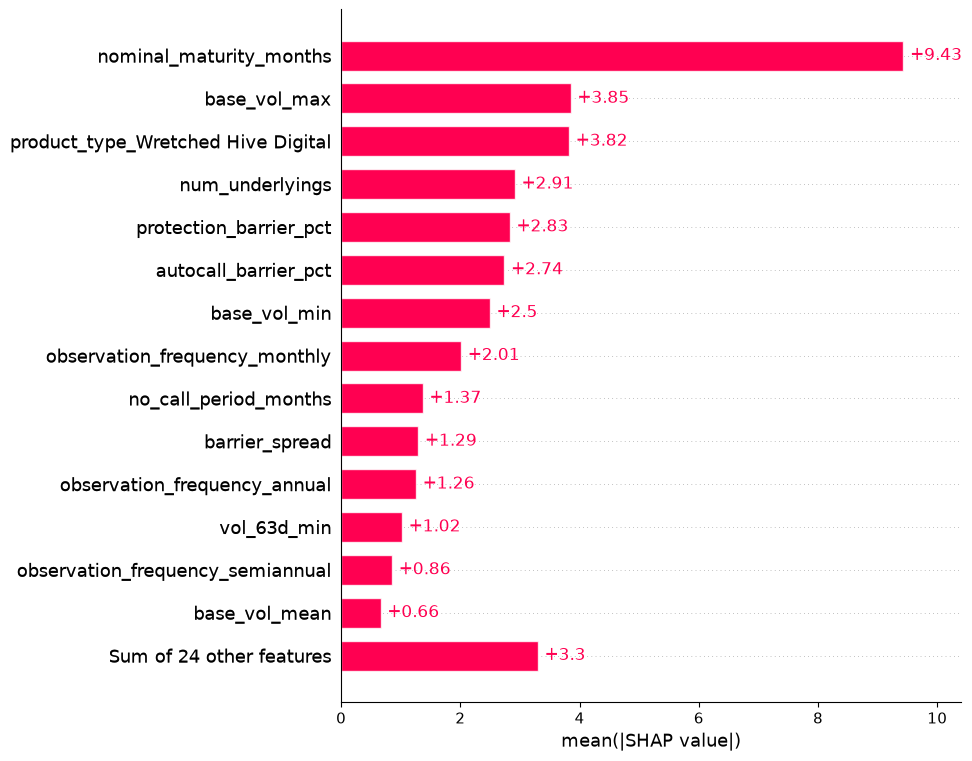

In [21]:
shap_model_name = 'XGBoost'
shap_model = xgboost_model

sample_size = min(1000, X_test.shape[0])
sample_idx = np.random.RandomState(42).choice(
    X_test.shape[0], sample_size, replace=False
)
X_shap = X_test.iloc[sample_idx]

try:
    explainer = shap.Explainer(shap_model, X_train)
    shap_values = explainer(X_shap)

    shap_importance = pd.DataFrame({
        'feature': X_train.columns,
        'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
    }).sort_values('mean_abs_shap', ascending=False)

    print(f'Modelo usado para SHAP: {shap_model_name}')
    print('Top 15 variables por impacto medio absoluto (SHAP):')

    shap.plots.bar(shap_values, max_display=15)
    plt.show()
except Exception as ex:
    print(f'No se pudo generar SHAP con {shap_model_name}: {ex}')

In [22]:
# Variables con menos impacto SHAP:
display(shap_importance.nsmallest(5, 'mean_abs_shap'))

,feature,mean_abs_shap
20,product_type_Mandalorian Twin-Win,0.007352
30,counterparty_Banco de Coruscant,0.008174
36,counterparty_Nal Hutta Traders,0.009281
34,counterparty_Jabba Asset Management,0.009917
35,counterparty_Kamino Cloning Trust,0.011027


## Interpretación de resutados

La variable nominal_maturity_months es la que más peso tiene porque marca la duración máxima del contrato, estableciendo el techo temporal evidente ya que un producto diseñado a un año nunca podrá llegar a durar cinco. Le sigue base_vol_max, lo cual tiene sentido financiero en estructuras worst-of, ya que el subyacente con mayor volatilidad estructural es el más propenso a sufrir caídas pronunciadas y actuar como el "activo más débil", impidiendo que la cesta supere la barrera y alargando la vida del producto. Por último, destaca product_type_Wretched Hive Digital, lo que indica que las condiciones contractuales y la estructura de pagos propia de este tipo de producto condicionan fuertemente la probabilidad de autocall frente a otros formatos más convencionales.  


Por el contrario, las variables con una importancia prácticamente nula, como las distintas contrapartes (counterparty_Banco de Coruscant, counterparty_Jabba Asset Management, counterparty_Nal Hutta Traders) o tipos de producto específicos como el Mandalorian Twin-Win, apenas influyen en la predicción final. Esto tiene sentido, ya que la duración esperada de la estructura depende estrictamente de las condiciones técnicas del contrato (vencimiento nominal, barreras) y de la dinámica de volatilidad del mercado, y no de qué cliente institucional o entidad solicite la cotización en la mesa.